# Animal Crossing Insects
Sofia Gabriela Aguilar

036019

ICC CETYS 2026

## Dataset origin:
https://www.kaggle.com/datasets/jessicali9530/animal-crossing-new-horizons-nookplaza-dataset?select=insects.csv

## Objective (Regression)
Predict insect selling price "Sell" using insect attributes and seasonal details.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

In [2]:
data = pd.read_csv("insects.csv")
data.head()

,#,Name,Sell,Where/How,Weather,Total Catches to Unlock,Spawn Rates,NH Jan,NH Feb,NH Mar,...,SH Oct,SH Nov,SH Dec,Color 1,Color 2,Icon Filename,Critterpedia Filename,Furniture Filename,Internal ID,Unique Entry ID
0,10,agrias butterfly,3000,Flying near flowers,Any except rain,20,5,NaN,NaN,NaN,...,8 AM – 5 PM,8 AM – 5 PM,8 AM – 5 PM,Pink,Green,Ins6,InsectMiirotateha,FtrInsectMiirotateha,620,aj95rMzdbSbvZy9A2
1,69,ant,80,On rotten turnips,Any weather,0,0,All day,All day,All day,...,All day,All day,All day,Black,White,Ins26,InsectAri,FtrInsectAri,588,QZpmczZu4hW2a4Rpv
2,14,Atlas moth,3000,On trees (any kind),Any weather,20,5,NaN,NaN,NaN,...,7 PM – 4 AM,7 PM – 4 AM,7 PM – 4 AM,Orange,Yellow,Ins10,InsectYonagunisan,FtrInsectYonagunisan,652,u2GhYQJXDCQKp7AQ8
3,68,bagworm,600,Shaking trees (hardwood or cedar only),Any weather,0,50,All day,All day,All day,...,All day,All day,All day,Brown,Blue,Ins36,InsectMinomushi,FtrInsectMinomushi,622,QvxgCm82JqHsDknY4
4,34,banded dragonfly,4500,Flying near water,Any except rain,50,7,NaN,NaN,NaN,...,NaN,8 AM – 5 PM,8 AM – 5 PM,Black,Yellow,Ins24,InsectOniyanma,FtrInsectOniyanma,635,pCFep58D6QusMSvR7


Inspect column data types and basic statistics to be able to understand what features are available and how they may connect to the target variable "Sell".


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   #                        80 non-null     int64 
 1   Name                     80 non-null     object
 2   Sell                     80 non-null     int64 
 3   Where/How                80 non-null     object
 4   Weather                  80 non-null     object
 5   Total Catches to Unlock  80 non-null     int64 
 6   Spawn Rates              80 non-null     object
 7   NH Jan                   20 non-null     object
 8   NH Feb                   21 non-null     object
 9   NH Mar                   27 non-null     object
 10  NH Apr                   36 non-null     object
 11  NH May                   43 non-null     object
 12  NH Jun                   48 non-null     object
 13  NH Jul                   61 non-null     object
 14  NH Aug                   63 non-null     obj

In [4]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
#,80.0,NaN,NaN,NaN,40.5,23.2379,1.0,20.75,40.5,60.25,80.0
Name,80,80,agrias butterfly,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sell,80.0,NaN,NaN,NaN,2220.5,3209.388877,10.0,237.5,600.0,2625.0,12000.0
Where/How,80,25,On the ground,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weather,80,3,Any weather,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Catches to Unlock,80.0,NaN,NaN,NaN,17.5,30.08427,0.0,0.0,0.0,20.0,100.0
Spawn Rates,80,19,5,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NH Jan,20,9,All day,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NH Feb,21,9,All day,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NH Mar,27,9,All day,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Feature engineering: seasonality
The dataset includes monthly availability columns for both hemispheres:
- NH = Northern Hemisphere
- SH = Southern Hemisphere

Missing values in these monthly columns typically indicate that an insect is not available during that month in the corresponding hemisphere.

To simplify the dataset, I decided to represent seasonal availability using numeric features instead of individual monthly columns:
- "Months_Available_NH": number of months the insect is available in the Northern Hemisphere
- "Months_Available_SH": number of months the insect is available in the Southern Hemisphere

In [5]:
nh_month_cols = [c for c in data.columns if c.startswith("NH ")]
sh_month_cols = [c for c in data.columns if c.startswith("SH ")]

data["Months_Available_NH"] = data[nh_month_cols].notna().sum(axis=1)
data["Months_Available_SH"] = data[sh_month_cols].notna().sum(axis=1)
data[["Months_Available_NH", "Months_Available_SH"]].head()

,Months_Available_NH,Months_Available_SH
0,6,6
1,12,12
2,6,6
3,12,12
4,6,6


Visualize distributions for numeric variables and frequency counts for key categorical variables.

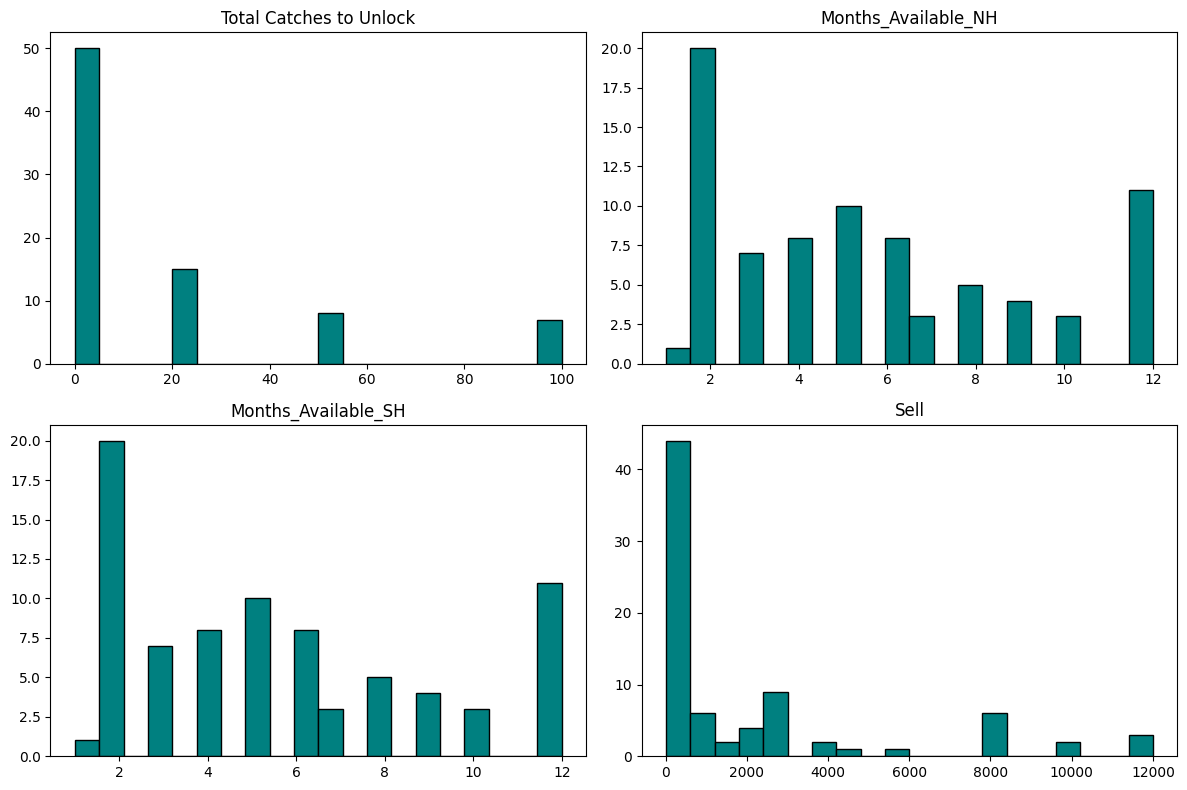

In [14]:
numerical_cols = ["Total Catches to Unlock", "Months_Available_NH", "Months_Available_SH", "Sell"]
numerical_cols = [c for c in numerical_cols if c in data.columns]

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()
for i, col in enumerate(numerical_cols):
    axs[i].hist(data[col].dropna(), bins=20, color="teal", edgecolor="black")
    axs[i].set_title(col)
plt.tight_layout()
plt.show()

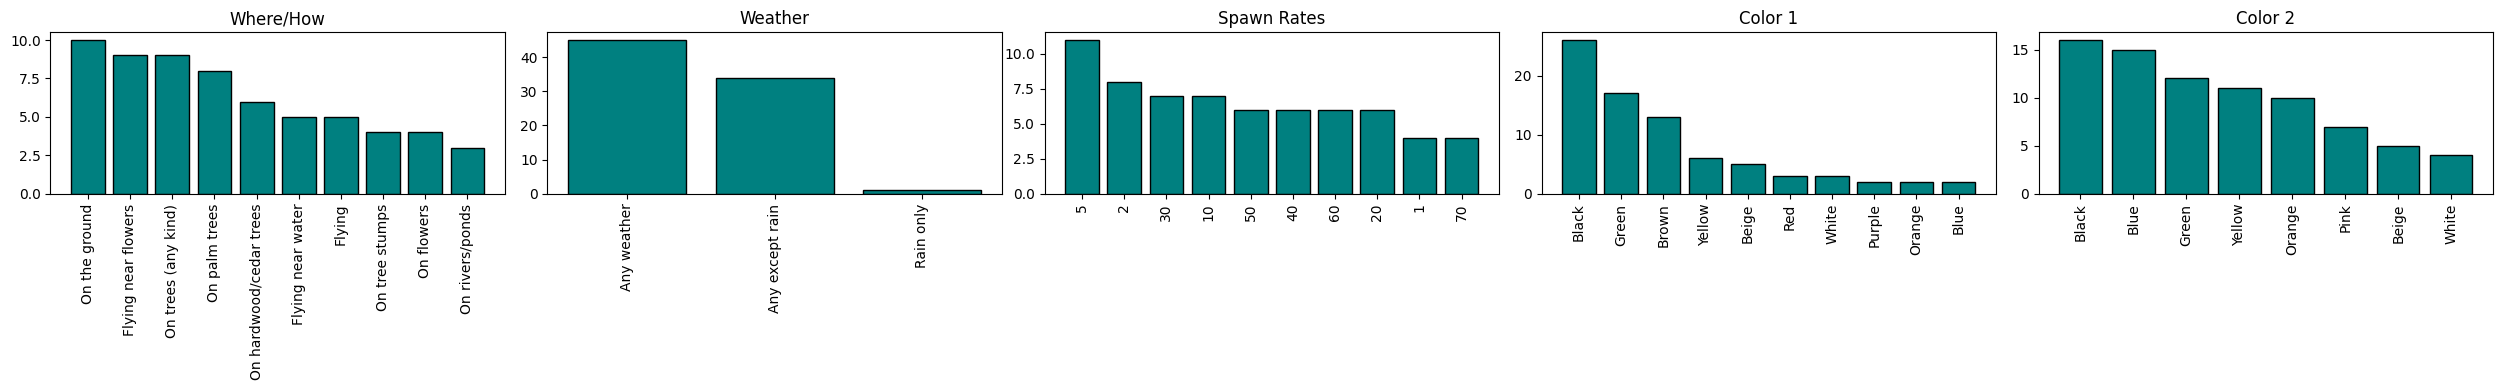

In [15]:
categorical_cols = ["Where/How", "Weather", "Spawn Rates", "Color 1", "Color 2"]
categorical_cols = [c for c in categorical_cols if c in data.columns]

fig, axs = plt.subplots(1, len(categorical_cols), figsize=(5 * len(categorical_cols), 4))
if len(categorical_cols) == 1:
    axs = [axs]
for ax, col in zip(axs, categorical_cols):
    counts = data[col].value_counts(dropna=False).head(10)
    ax.bar(counts.index.astype(str), counts.values, color="teal", edgecolor="black")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

The regression target is "Sell". We visualize its distribution.


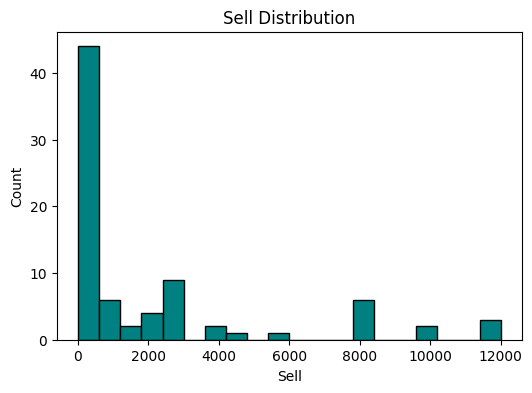

In [16]:
plt.figure(figsize=(6, 4))
plt.hist(data["Sell"].dropna(), bins=20, color="teal", edgecolor="black")
plt.title("Sell Distribution")
plt.xlabel("Sell")
plt.ylabel("Count")
plt.show()

## Missing values
Missing values are examined per column. For month availability columns, missing values are expected and represent “not available”.

In [9]:
missing_counts = data.isnull().sum().sort_values(ascending=False)
missing_percent = (data.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})

missing_summary.head(25)

,missing_count,missing_percent
NH Jan,60,75.00
SH Jul,60,75.00
SH Jun,60,75.00
NH Dec,60,75.00
NH Feb,59,73.75
SH Aug,59,73.75
SH May,53,66.25
NH Nov,53,66.25
SH Sep,53,66.25
NH Mar,53,66.25


Define features X and the target y, then split into training and testing sets.

In [10]:
target = "Sell"

feature_cols = [
    "Total Catches to Unlock",
    "Months_Available_NH",
    "Months_Available_SH",
    "Where/How",
    "Weather",
    "Spawn Rates",
    "Color 1",
    "Color 2"
]
feature_cols = [c for c in feature_cols if c in data.columns]
X = data[feature_cols].copy()
y = data[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((64, 8), (16, 8))

Build a preprocessing pipeline to prepare the data for the model:
- Numeric features are filled using the median and then scaled.
- Categorical features are filled using the most common value and converted into numeric form using one-hot encoding.

Using a pipeline ensures that all preprocessing steps are learned only from the training data, which helps to prevent data leakage.


In [11]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Total Catches to Unlock',
                                  'Months_Available_NH',
                                  'Months_Available_SH']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Where/How', 'Weather', 'Spawn Rates',
                                  'Color 1', 'Color 2'])])

## Model pipeline and training
Integrate preprocessing and model into a single sklearn Pipeline.

In [17]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

regression_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

regression_pipeline.fit(X_train, y_train)
#Categorical variables are converted to numeric format using OneHotEncoder inside the preprocessing pipeline.

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Total Catches to Unlock',
                                                   'Months_Available_NH',
                                                   'Months_Available_SH']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Where/How', 'Weather',
                                                   'Spawn Rates', 'Color 1',
                                                   'Color 2'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, random_state=42))])

## Predictions

In [13]:
preds = regression_pipeline.predict(X_test)

results = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": preds
})

results.head(20)

,y_true,y_pred
0,12000,9496.900000
1,3000,2721.766667
2,550,338.566667
3,8000,7041.533333
4,200,707.700000
5,2000,5292.533333
6,350,548.933333
7,8000,4522.866667
8,4500,5508.800000
9,160,419.366667


## Main findings
- "Sell" spans a wide range of values, suggesting different insect attributes may influence price
- Month availability columns contain many missing values that represent “not available”
- We engineered "Months_Available_NH" and "Months_Available_SH" to represent seasonality numerically.
- Preprocessing and modeling were combined into a single sklearn Pipeline to avoid data leakage

🦗    🐛    🦋